# Introduction to Computer Vision — Practice Notebook
### ITI Summer Training

This notebook accompanies the *Introduction to Computer Vision* lecture. Work through each section in order — later exercises build on ideas from earlier ones (pixels → color spaces → transformations → convolution → pooling → labels/accuracy).

**How to use this notebook:**
- Each section starts with a short **Notes** recap of the relevant slide content.
- Then comes a **Task** describing what you need to code.
- A **Hints** block follows with pointers (functions/formulas to use) — try to solve it yourself before reading the hints.
- Cells marked `# TODO` are where you write your code. Do not worry about the exact output formatting, just make sure the logic is correct.

Run the setup cell below first.


## Setup

We'll use `numpy` for array/pixel manipulation, `matplotlib` for displaying images, and `opencv-python` (`cv2`) for some built-in operations you can compare your manual implementations against. `scikit-image` provides a couple of sample images so you don't need to upload your own files.


cat_img shape: (300, 451, 3) uint8
astro_img shape: (512, 512, 3) uint8


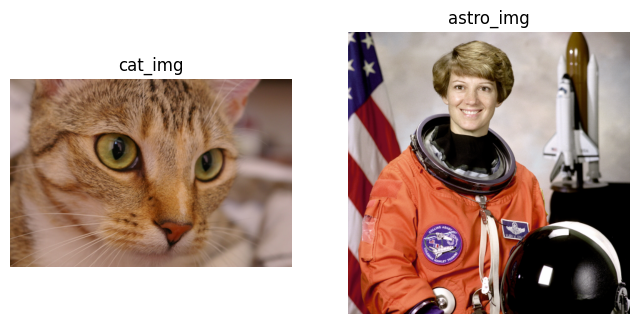

In [1]:
# If a package is missing, uncomment and run:
!pip install opencv-python scikit-image matplotlib numpy --quiet

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

%matplotlib inline

# Two sample color images (RGB, uint8) we'll use throughout the notebook
cat_img = data.chelsea()        # a color photo of a cat, shape (H, W, 3)
astro_img = data.astronaut()    # a color photo of a person, shape (H, W, 3)

print("cat_img shape:", cat_img.shape, cat_img.dtype)
print("astro_img shape:", astro_img.shape, astro_img.dtype)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(cat_img); plt.title("cat_img"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(astro_img); plt.title("astro_img"); plt.axis('off')
plt.show()


## Part 1 — Images as Numerical Data (Pixels)

**Notes:** An image is just a grid (matrix / array) of numbers. A **grayscale** image is a 2D array where each pixel value ranges from 0 (black) to 255 (white). A **color (RGB)** image is a 3D array with shape `(height, width, 3)` — depth 3 for the Red, Green, and Blue channels. Pixels are accessed with `(row, col)` = `(y, x)` coordinates, and Python/NumPy is zero-indexed.

### Task 1.1
Convert `cat_img` to grayscale **without using `cv2.cvtColor`** — implement it yourself using the *average method* described in the slides:

$$grayscale = \frac{R+G+B}{3}$$

Store the result in `cat_gray_avg` as a `uint8` array with the same height/width as `cat_img` (no channel dimension).

### Task 1.2
Print:
- The image's width and height (not just `.shape`)
- The pixel value at row `100`, column `50` in `cat_gray_avg`
- The **minimum** and **maximum** pixel values in `cat_gray_avg`

**Hints:**
- `cat_img[:, :, 0]` gives you the Red channel, `[:, :, 1]` Green, `[:, :, 2]` Blue.
- Cast to a larger type (e.g. `.astype(np.float32)`) before averaging so values don't overflow/wrap around, then cast back with `.astype(np.uint8)`.
- `img.shape` returns `(height, width, channels)` — width is the number of *columns*.
- Use `.min()` / `.max()` on the array.


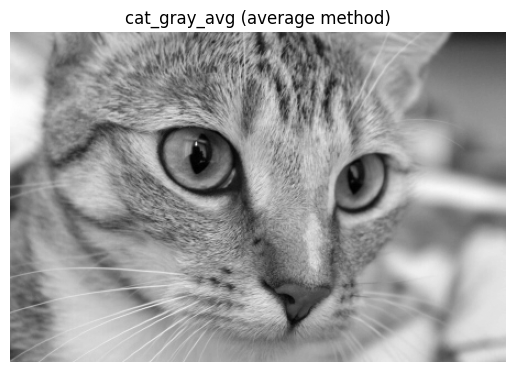

In [2]:
# Task 1.1: manual grayscale conversion (average method)
# TODO: implement without cv2.cvtColor
cat_gray_avg = np.mean(cat_img, axis=2).astype(np.uint8)

# --- quick sanity check / visualization (uncomment once implemented) ---
plt.imshow(cat_gray_avg, cmap='gray')
plt.title("cat_gray_avg (average method)")
plt.axis('off')
plt.show()


In [3]:
# Task 1.2: pixel/shape queries
# TODO

height, width = cat_gray_avg.shape

pixel_value = cat_gray_avg[100, 50]

min_val = cat_gray_avg.min()
max_val = cat_gray_avg.max()

print("width:", width, "height:", height)
print("pixel at (row=100, col=50):", pixel_value)
print("min:", min_val, "max:", max_val)


width: 451 height: 300
pixel at (row=100, col=50): 116
min: 3 max: 194


## Part 2 — Color Spaces (RGB, Grayscale conversion methods, HSV)

**Notes:** There are 3 common ways to convert RGB → Grayscale:

- **Lightness**: `(min(R,G,B) + max(R,G,B)) / 2`
- **Average**: `(R + G + B) / 3` (you already did this in Part 1)
- **Luminosity** (best, matches human perception): `0.3*R + 0.59*G + 0.11*B`

Also recall **HSV** (Hue, Saturation, Value) is often better than RGB for tasks like object tracking or color thresholding, because the Hue channel stays fairly stable under different lighting, while the Value channel captures brightness separately. In OpenCV, Hue is stored in the range `0–179` (not `0–360`) to fit in 8 bits.

### Task 2.1
Implement the **Lightness** and **Luminosity** grayscale methods as functions, apply them to `cat_img`, and display all **three** grayscale versions (average, lightness, luminosity) side by side to compare.

### Task 2.2
Convert `cat_img` to HSV using `cv2.cvtColor` (note: OpenCV expects BGR order by default — `cat_img` from skimage is RGB, so use `cv2.COLOR_RGB2HSV`). Display the H, S, and V channels separately as grayscale images, and print the min/max of the H channel to confirm it's within `0–179`.

**Hints:**
- Write small helper functions `grayscale_lightness(img)` and `grayscale_luminosity(img)` that take an RGB `uint8` array and return a 2D `uint8` array.
- `cv2.cvtColor(img, cv2.COLOR_RGB2HSV)` returns an array of shape `(H, W, 3)`; slice `[:, :, 0]`, `[:, :, 1]`, `[:, :, 2]` for H, S, V.
- Use `plt.subplot(1, 3, i)` to show 3 images in a row.


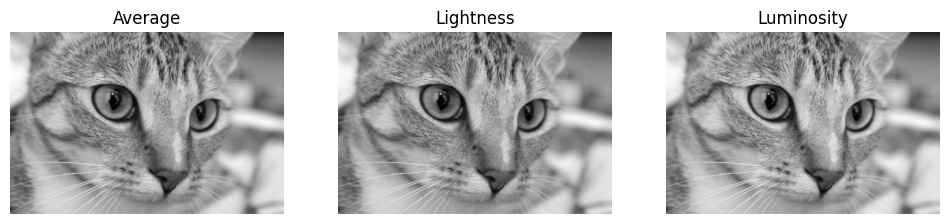

In [4]:
# Task 2.1: lightness & luminosity grayscale methods
def grayscale_lightness(img):
    # TODO
    img_f = img.astype(np.float32)
    min_c = np.min(img_f, axis=2)
    max_c = np.max(img_f, axis=2)
    lightness = (min_c + max_c) / 2.0
    return lightness.astype(np.uint8)

def grayscale_luminosity(img):
    # TODO
    img_f = img.astype(np.float32)
    # R * 0.3 + G * 0.59 + B * 0.11
    luminosity = 0.3 * img_f[:, :, 0] + 0.59 * img_f[:, :, 1] + 0.11 * img_f[:, :, 2]
    return luminosity.astype(np.uint8)

cat_gray_light = grayscale_lightness(cat_img)       # TODO: call grayscale_lightness(cat_img)
cat_gray_lumin = grayscale_luminosity(cat_img)       # TODO: call grayscale_luminosity(cat_img)

# TODO: display cat_gray_avg, cat_gray_light, cat_gray_lumin side-by-side with titles
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(cat_gray_avg, cmap='gray'); plt.title("Average"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(cat_gray_light, cmap='gray'); plt.title("Lightness"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cat_gray_lumin, cmap='gray'); plt.title("Luminosity"); plt.axis('off')
plt.show()


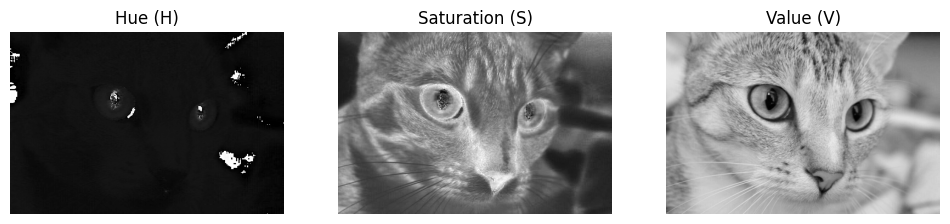

Hue Channel Minimum: 0
Hue Channel Maximum: 179


In [5]:
# Task 2.2: HSV conversion
# TODO
cat_hsv = cv2.cvtColor(cat_img, cv2.COLOR_RGB2HSV)   # convert cat_img (RGB) to HSV

H, S, V = cat_hsv[:, :, 0], cat_hsv[:, :, 1], cat_hsv[:, :, 2]  # TODO: split channels

# TODO: display H, S, V as grayscale side by side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue (H)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation (S)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value (V)")
plt.axis('off')

plt.show()

# TODO: print min/max of H
print("Hue Channel Minimum:", H.min())
print("Hue Channel Maximum:", H.max())


## Part 3 — Coordinate Transformations (Translation, Rotation, Scaling)

**Notes:** Coordinate transformations change where pixels are located, using matrices. For example a translation matrix that shifts an image by `(tx, ty)` pixels is:

$$
\begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix}
$$

OpenCV's `cv2.warpAffine(img, M, (width, height))` applies any 2x3 affine matrix `M` to an image.

### Task 3.1
Build a translation matrix that shifts `astro_img` 80 pixels right and 60 pixels down (matching the slide example), and apply it with `cv2.warpAffine`. Display the original and translated image side by side.

### Task 3.2
Use `cv2.getRotationMatrix2D` to rotate `astro_img` by 45 degrees around its center, **without changing its scale**. Display the result.

### Task 3.3
Scale `astro_img` down to half its width and height, then back up to the original size, and display both results next to the original. What do you notice about image quality after shrinking and re-enlarging?

**Hints:**
- `cv2.warpAffine(img, M, (width, height))` — note `(width, height)` order, not `(height, width)`!
- `cv2.getRotationMatrix2D(center, angle, scale)` returns a 2x3 matrix; `center = (width/2, height/2)`.
- `cv2.resize(img, (new_width, new_height))` for scaling.
- Answer the "what do you notice" question in a short markdown or comment.


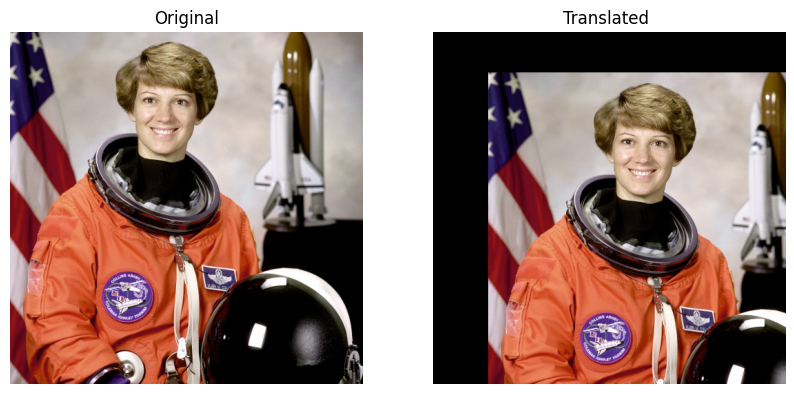

In [6]:
# Task 3.1: translation
h, w = astro_img.shape[:2]
tx, ty = 80, 60

# TODO: build the 2x3 translation matrix M_translate
M_translate = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(astro_img, M_translate, (w, h))  # TODO: cv2.warpAffine(astro_img, M_translate, (w, h))

# TODO: display original vs translated
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(astro_img); plt.title("Original"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(translated); plt.title("Translated "); plt.axis('off')
plt.show()


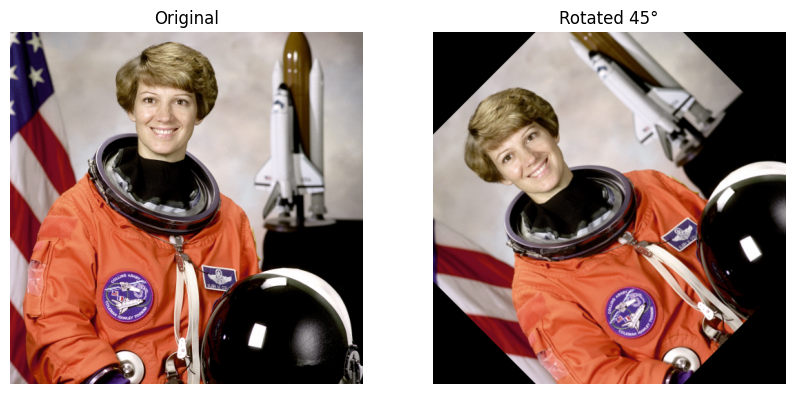

In [7]:
# Task 3.2: rotation
# TODO
center = (w / 2.0, h / 2.0)
M_rotate = cv2.getRotationMatrix2D(center, angle=45, scale=1.0)   # cv2.getRotationMatrix2D(center, angle=45, scale=1.0)
rotated = cv2.warpAffine(astro_img, M_rotate, (w, h))

# TODO: display original vs rotated
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(astro_img); plt.title("Original"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(rotated); plt.title("Rotated 45°"); plt.axis('off')
plt.show()


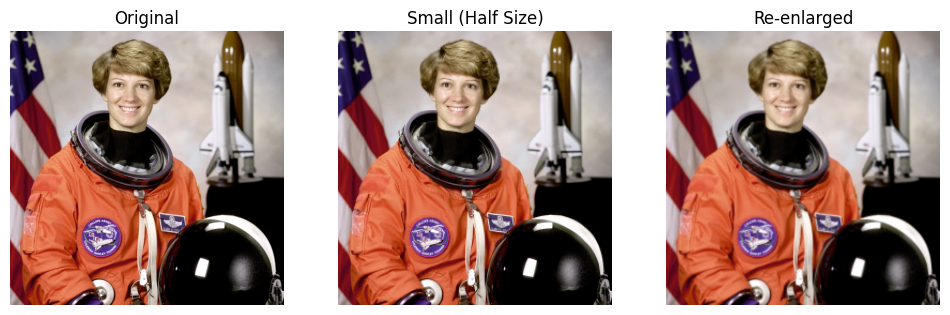

Original shape: (512, 512, 3)
Small shape: (256, 256, 3)
Re-enlarged shape: (512, 512, 3)


In [8]:
# Task 3.3: scaling down then up
# TODO
small = cv2.resize(astro_img, (w // 2, h // 2))   # resize to (w//2, h//2)
back_up = cv2.resize(small, (w, h)) # resize `small` back to (w, h)

# TODO: display original, small, back_up side by side
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(astro_img); plt.title("Original"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(small); plt.title("Small (Half Size)"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(back_up); plt.title("Re-enlarged"); plt.axis('off')
plt.show()

#-----------------------

print("Original shape:", astro_img.shape)
print("Small shape:", small.shape)
print("Re-enlarged shape:", back_up.shape)
#----------------------

# Your observation (edit this comment):
# When shrinking the image, high-frequency details (fine pixels) are lost.
# When re-enlarging it back to the original size, the lost details cannot be recovered,
# resulting in a pixelated image (loss of resolution).


## Part 4 — Convolution & Filters (Edge Detection)

**Notes:** A **convolution kernel** is a small matrix of weights. It's slid across the image; at each position, corresponding kernel and pixel values are multiplied and summed to produce one output pixel. High-pass filters (like the edge-detection kernel from the slides) emphasize regions where intensity changes quickly:

$$
K = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 0 \end{bmatrix}
$$

### Task 4.1
Implement your **own** `manual_convolve(image, kernel)` function **from scratch** (using nested loops is fine — don't use `cv2.filter2D` or `scipy` here) that:
- works on a single-channel (grayscale) `uint8` image
- uses **zero padding** so the output is the same size as the input
- returns a `uint8` array (clip values to the 0–255 range before casting)

### Task 4.2
Apply your function with the edge-detection kernel `K` above to a grayscale version of `astro_img`. Display the original grayscale image and the filtered result side by side.

### Task 4.3
Try at least one other kernel of your choice (e.g. a 3x3 **box blur**, where every value is `1/9`) and compare the output to Task 4.2's edge detection result.

**Hints:**
- Pad the image first with `np.pad(img, pad_width=1, mode='constant', constant_values=0)` for a 3x3 kernel.
- For every output pixel `(i, j)`, take the 3x3 neighborhood from the padded image, multiply elementwise with the kernel, and sum: `np.sum(neighborhood * kernel)`.
- Use `np.clip(value, 0, 255)` before converting to `uint8` to avoid wraparound artifacts.
- This will be slow (pure Python loops) — that's fine for a 300x300-ish image, but you can crop the image smaller if it's too slow for testing.


In [9]:
# Task 4.1: manual convolution
def manual_convolve(image, kernel):
    """
    image: 2D uint8 numpy array (grayscale)
    kernel: 2D numpy array (assume square, odd size e.g. 3x3)
    returns: 2D uint8 numpy array, same shape as `image`
    """
    # TODO: implement using zero padding + nested loops
    h, w = image.shape
    k_size = kernel.shape[0]
    pad = k_size // 2

    # 1. Zero Padding
    padded_img = np.pad(image, pad_width=pad, mode='constant', constant_values=0).astype(np.float32)

    # array ia impty to store result
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+k_size, j:j+k_size]
            # mult two matrix & sum
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

# quick self-test on a tiny 4x4 array with an edge kernel (optional, helps debug)
test_img = np.array([[10,10,10,0],
                      [10,10,10,0],
                      [10,10,10,0],
                      [10,10,10,0]], dtype=np.uint8)
edge_kernel = np.array([[1,0,-1],
                         [1,0,-1],
                         [1,0,-1]])
print(manual_convolve(test_img, edge_kernel))


[[ 0  0 20 20]
 [ 0  0 30 30]
 [ 0  0 30 30]
 [ 0  0 20 20]]


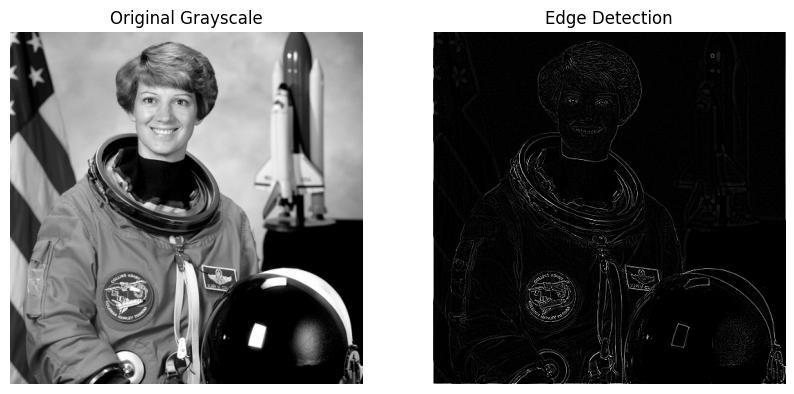

In [10]:
# Task 4.2: apply edge detection kernel to astro_img (grayscale)
astro_gray = cv2.cvtColor(astro_img, cv2.COLOR_RGB2GRAY)  # OK to use cv2 here, just for getting a grayscale input

K_edge = np.array([[0, -1, 0],
                    [-1, 4, -1],
                    [0, -1, 0]])

# TODO
astro_edges = manual_convolve(astro_gray, K_edge)

# TODO: display astro_gray vs astro_edges
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(astro_gray, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(astro_edges, cmap='gray'); plt.title("Edge Detection"); plt.axis('off')
plt.show()


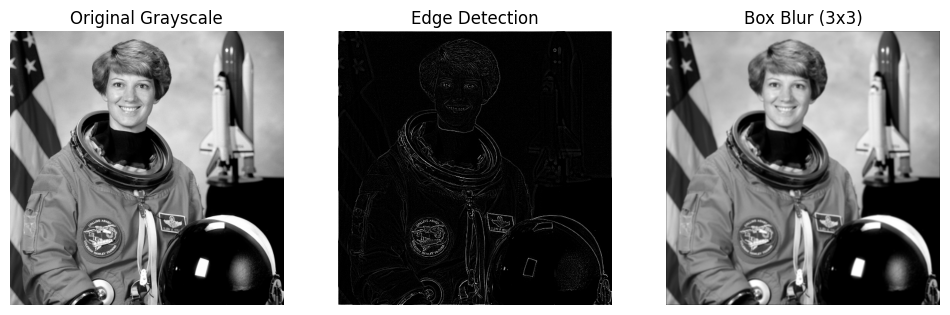

In [11]:
# Task 4.3: try another kernel (e.g. box blur)
K_blur = np.ones((3,3)) / 9.0

# TODO
astro_blur = manual_convolve(astro_gray, K_blur)

# TODO: display astro_gray, astro_edges, astro_blur side by side
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(astro_gray, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(astro_edges, cmap='gray'); plt.title("Edge Detection"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(astro_blur, cmap='gray'); plt.title("Box Blur (3x3)"); plt.axis('off')
plt.show()
# TODO: 1-2 sentence comment on what changed
# The edge-detection kernel acts as a high-pass filter that isolates sharp intensity transitions, leaving homogeneous areas dark.
# In contrast, the box blur kernel acts as a low-pass filter that averages neighboring pixel values, smoothing out high-frequency noise and details.


## Part 5 — Padding & Stride

**Notes:** Without padding, a kernel can't be centered on border pixels, so the output shrinks. **Stride** controls how many pixels the kernel jumps each step; larger strides mean faster computation but coarser coverage. The general formula for the output size of a convolution is:

$$
\text{output size} = \left\lfloor \frac{n + 2p - f}{s} \right\rfloor + 1
$$

where `n` = input size, `p` = padding, `f` = kernel size, `s` = stride.

### Task 5.1
Write a function `conv_output_size(n, p, f, s)` implementing the formula above.

### Task 5.2
Using `n=6, f=3` (matching the slide's stride example): compute and print the output size for
  (a) `p=0, s=1`
  (b) `p=0, s=2`
  (c) `p=1, s=1` (the "same" padding case for a 3x3 kernel)

### Task 5.3
Modify your `manual_convolve` from Part 4 into `manual_convolve_stride(image, kernel, stride, padding)` that supports an arbitrary stride and padding amount, and returns an output whose shape matches what `conv_output_size` predicts. Test it on `astro_gray` with `K_edge`, `stride=2`, `padding=0`, and print the resulting shape to confirm it matches your formula.

**Hints:**
- `//` is Python's floor-division operator.
- When looping with stride `s`, your output indices `(i, j)` should map to top-left input corner `(i*s, j*s)` in the padded image.
- Double check off-by-one issues by comparing against `conv_output_size`.


In [12]:
# Task 5.1
def conv_output_size(n, p, f, s):
    # TODO
    """
    n: input size (width/height)
    p: padding amount
    f: kernel filter size
    s: stride step size
    """
    return ((n + 2 * p - f) // s) + 1


In [13]:
# Task 5.2
# TODO: print results for the three (p, s) combinations, n=6, f=3
n = 6
f = 3

# (a) p=0, s=1
size_a = conv_output_size(n, p=0, f=f, s=1)
print("(a) Output size (p=0, s=1):", size_a)

# (b) p=0, s=2
size_b = conv_output_size(n, p=0, f=f, s=2)
print("(b) Output size (p=0, s=2):", size_b)

# (c) p=1, s=1 ("same" padding)
size_c = conv_output_size(n, p=1, f=f, s=1)
print("(c) Output size (p=1, s=1):", size_c)


(a) Output size (p=0, s=1): 4
(b) Output size (p=0, s=2): 2
(c) Output size (p=1, s=1): 6


In [14]:
# Task 5.3
def manual_convolve_stride(image, kernel, stride=1, padding=0):
    h, w = image.shape
    k_size = kernel.shape[0]

    out_h = conv_output_size(h, padding, k_size, stride)
    out_w = conv_output_size(w, padding, k_size, stride)

    # Padding
    padded_img = np.pad(image, pad_width=padding, mode='constant', constant_values=0).astype(np.float32)

    output = np.zeros((out_h, out_w), dtype=np.float32)

    # scane image -> stride
    for i in range(out_h):
        for j in range(out_w):
            r_start = i * stride
            c_start = j * stride
            region = padded_img[r_start:r_start+k_size, c_start:c_start+k_size]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

# TODO: run on astro_gray with K_edge, stride=2, padding=0
astro_strided = manual_convolve_stride(astro_gray, K_edge, stride=2, padding=0)

# TODO: print output.shape and compare with conv_output_size(...)
print("Output image shape from function:", astro_strided.shape)

expected_h = conv_output_size(astro_gray.shape[0], 0, K_edge.shape[0], 2)
expected_w = conv_output_size(astro_gray.shape[1], 0, K_edge.shape[1], 2)
print("Expected shape from conv_output_size:", (expected_h, expected_w))


Output image shape from function: (255, 255)
Expected shape from conv_output_size: (255, 255)


## Part 6 — Pooling (Downsampling)

**Notes:** Pooling reduces the spatial size of an image/feature map by summarizing small regions — **max pooling** takes the maximum value in each region, which keeps the most "salient" (strongest) signal while discarding the rest.

### Task 6.1
Implement `max_pool(image, pool_size, stride)` from scratch (no `cv2`/`skimage` pooling functions) that performs non-overlapping (or overlapping, depending on stride) max pooling on a 2D array.

### Task 6.2
Apply `max_pool` to `astro_gray` with `pool_size=2, stride=2`. Print the shapes before and after, and display both images side by side.

**Hints:**
- With `pool_size=f` and `stride=s`, the output size follows the same formula as Task 5.1 but with `p=0`: `output = (n - f)//s + 1`.
- For each output cell, take the `f x f` window from the input and use `.max()`.
- Loop over rows/cols with step `stride`, same pattern as Task 5.3.


In [15]:
# Task 6.1
def max_pool(image, pool_size=2, stride=2):
    # TODO
    h, w = image.shape

    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1

    output = np.zeros((out_h, out_w), dtype=image.dtype)

    for i in range(out_h):
        for j in range(out_w):
            r_start = i * stride
            c_start = j * stride
            region = image[r_start:r_start+pool_size, c_start:c_start+pool_size]
            output[i, j] = region.max()

    return output


original shape: (512, 512)
pooled shape: (256, 256)


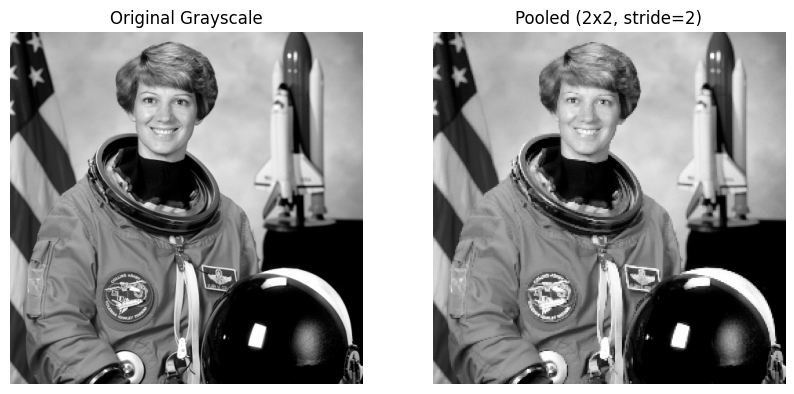

In [16]:
# Task 6.2
# TODO
pooled = max_pool(astro_gray, 2, 2)

print("original shape:", astro_gray.shape)
print("pooled shape:", pooled.shape)

# TODO: display astro_gray vs pooled
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(astro_gray, cmap='gray'); plt.title("Original Grayscale"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(pooled, cmap='gray'); plt.title("Pooled (2x2, stride=2)"); plt.axis('off')
plt.show()


## Part 7 — Labels and Accuracy

**Notes:** Machine learning models need **numerical** labels, not text. For binary classes we use **integer encoding** (e.g. `night=0`, `day=1`); for more than 2 classes we often use **one-hot encoding** (a list of 0s with a single 1 marking the class).

Accuracy is defined as:

$$
\text{accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}
$$

### Task 7.1
Given the list of categorical labels below, write code that:
- integer-encodes them (`"night" -> 0`, `"day" -> 1`)
- prints the resulting integer-encoded list

```python
labels = ["day", "day", "night", "day", "night", "night", "day"]
```

### Task 7.2
Given the class list `["cat", "tiger", "hippopotamus", "dog"]`, write a function `one_hot(label, classes)` that returns the one-hot encoded list for a given label string. Test it on `"tiger"` and `"dog"`.

### Task 7.3
Write a function `accuracy(true_labels, predicted_labels)` (both integer-encoded lists/arrays of equal length) that returns the accuracy as defined above. Test it on:

```python
true_labels =      [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
predicted_labels =  [1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
```
It should print something close to `0.8` (verify by hand!).

**Hints:**
- For 7.1, a dictionary mapping `{"night": 0, "day": 1}` plus a list comprehension is the cleanest approach.
- For 7.2, `classes.index(label)` gives you the position of the `1` in the one-hot vector.
- For 7.3, use `np.array(...)` and elementwise comparison (`==`), then `.mean()` gives you the accuracy directly (True=1, False=0).


In [17]:
# Task 7.1
labels = ["day", "day", "night", "day", "night", "night", "day"]

# TODO
label_map = {"night": 0, "day": 1}
# Convert using List Comprehension
encoded_labels = [label_map[label] for label in labels]

print(encoded_labels)


[1, 1, 0, 1, 0, 0, 1]


In [18]:
# Task 7.2
classes = ["cat", "tiger", "hippopotamus", "dog"]

def one_hot(label, classes):
    # TODO
    vec = [0] * len(classes)

    idx = classes.index(label)
    vec[idx] = 1
    return vec

print(one_hot("tiger", classes))
print(one_hot("dog", classes))


[0, 1, 0, 0]
[0, 0, 0, 1]


In [19]:
# Task 7.3
def accuracy(true_labels, predicted_labels):
    # TODO
    true_arr = np.array(true_labels)
    pred_arr = np.array(predicted_labels)

    # (True=1, False=0)
    return np.mean(true_arr == pred_arr)

true_labels =      [1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
predicted_labels =  [1, 0, 0, 1, 0, 1, 1, 0, 1, 1]

print("Accuracy:", accuracy(true_labels, predicted_labels))


Accuracy: 0.8


## Part 8 — Conceptual Check (short answers)

Answer the following in a sentence or two each, in the markdown cell below (double-click to edit):

1. What is the key difference between **image classification**, **object detection**, and **image segmentation**?
2. Why might you prefer to work in the **HSV** color space instead of RGB for a color-based object-tracking task?
3. Why do we use **zero-padding** before convolution instead of just letting the output shrink?
4. What does a larger **stride** trade off against smaller strides?
5. Why do we convert categorical labels (like `"cat"`, `"dog"`) into numerical form before training a model?


**Your answers:**

1. mage Classification assigns a single label to the whole image.

   Object Detection identifies and locates multiple objects using bounding boxes.

   Image Segmentation classifies every single pixel in the image to outline exact object boundaries.

2. HSV separates color information (Hue) from lighting and brightness (Value), making color-based tracking much more robust against shadows and changing illuminations compared to RGB.

3. Zero-padding preserves the spatial dimensions (height and width) of the image across convolutional layers and allows the filter to process edge/corner pixels as effectively as center pixels.

4. A larger stride speeds up computation and reduces the output spatial resolution, but it trades off fine-grained feature details and high-frequency spatial information.

5. Machine learning algorithms and neural networks perform mathematical operations (like matrix multiplication and optimization loss functions), which require numerical matrix inputs rather than raw string text.


---
## Wrap-up

Once you've completed all sections, restart the kernel and run all cells top-to-bottom (`Kernel > Restart & Run All`) to make sure everything works in order before submitting.
